In [30]:
# Choose a random number of 6 digits. Make sure that you keep a copy of this number and avoid trivial numbers, such as 000000 or 123456 -- thank you!
# number: 145236


# Assignment 1 - Visualisation and Performance Evaluation

First assessed coursework for the course: Técnicas e Algoritmos em Ciência de Dados 

## General guidelines:

* This work must be entirely original. You are allowed to research documentation for specific libraries, but copying solutions from the internet or your classmates is strictly prohibited. Any such actions will result in a deduction of points for the coursework.
* Please enter your code in the designated areas of the notebook. You can create additional code cells to experiment with, but __make sure to place your final solutions where they are requested in the notebook.__
* The notebook already imports all the necessary libraries for this assignment at the beginning. Although you are allowed to import other libraries, it is not necessary.
* Before submitting your work, make sure to rename the file to your random number that you created above (for example, 289479.ipynb).
* Do not use AI tools, such as ChatGPT, Copilot, Gemini, etc., this work is designed for you to get familiarized with important concepts that require hands-on experience.
* __Remember__, in case of some suspicious activity, such as copying code from the internet or your classmates and using AI tools, the course work and laboratories will be checked, for each laboratory considerated inappropriate, the student will loss the corresponding points.

## Notebook Overview:

1. [Data Loading and Visualisation](#Data-Loading-and-Visualisation) (20%)
2. [Binary Classification Building a PR curve](#Binary-Classification-Building-a-PR-curve) (50%)
3. [Regression RMSE](#Regression-RMSE) (30%)

In [31]:
%matplotlib inline
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score

## Data Loading and Visualisation

* Load the diamond.csv dataset from the folder "data" that is in the same directory as this notebook. If you want, you can download the dataset from [here](https://www.kaggle.com/datasets/shivam2503/diamonds).
* __Important:__ to ensure proper execution of your code, you need to either place the downloaded .csv file in the same working directory as the program or specify the correct path to the file.
* Load the data into a pandas `DataFrame`
* Clean the dataset by removing any datapoint with missing values and datapoints that are repeated

In [ ]:
# Load the data and clean it
# your code goes here

df = pd.read_csv('../../data/diamonds.csv')
df = df.dropna()
df = df.drop_duplicates()
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


* For each feature in the dataset, create a figure with two subplots one on top of the other.
    * In the first subplot, plot a histogram of the values of the feature for all classes combined. 
    * In the second subplot, plot a histogram of the values of the feature for each class separately. Use the column “cut” as the class identifier, and a different color for each class. 
    

* __Note:__ 
    * If the data contains a column "Id" that you can ignore or drop, as it is not relevant for the analysis.
    * All your histogrmas should have 50 bins and should be normalized (i.e., the area under the histogram should sum to 1). 

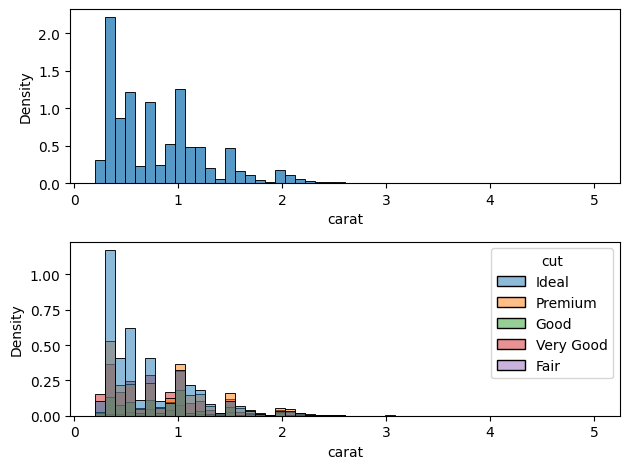

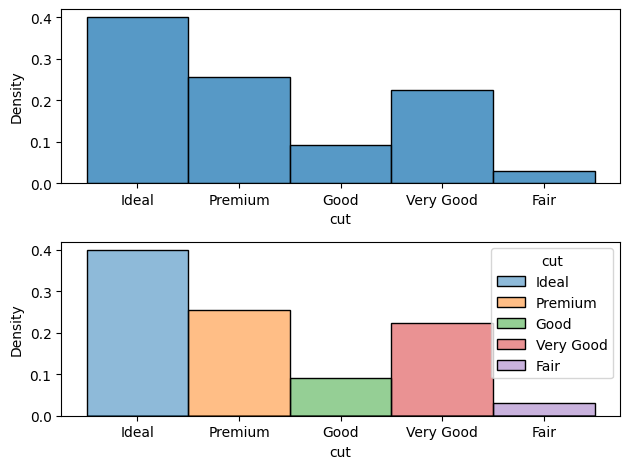

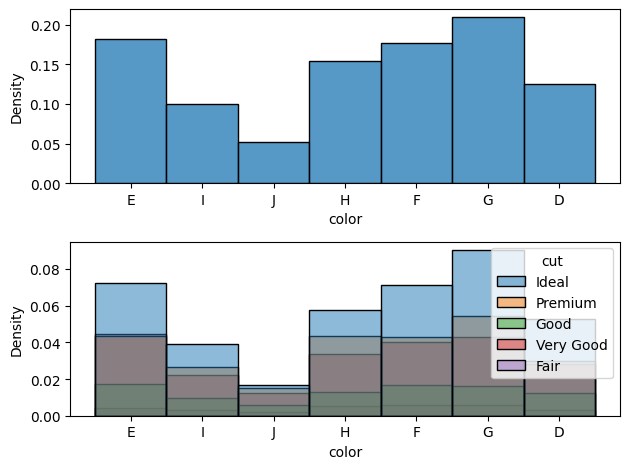

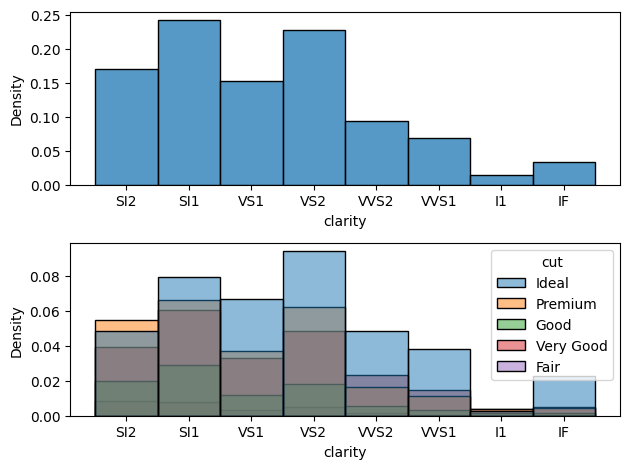

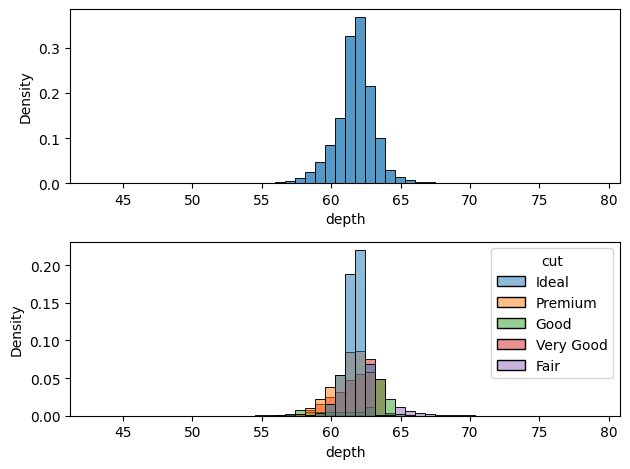

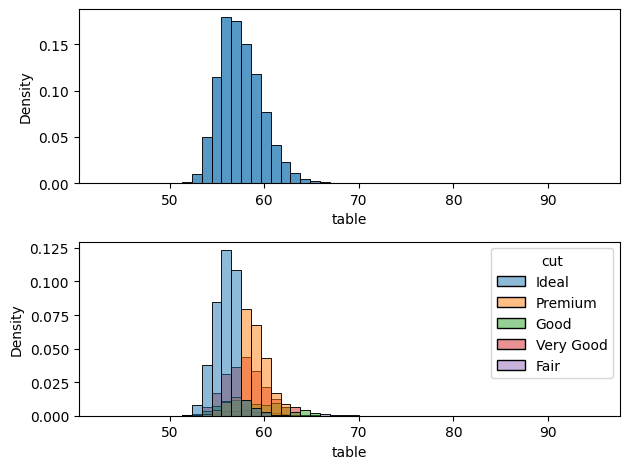

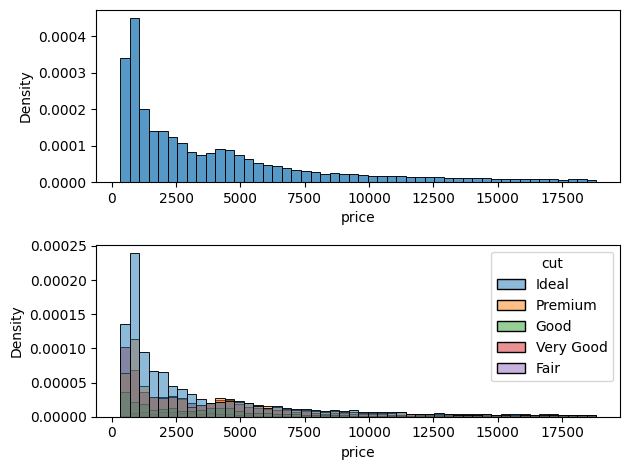

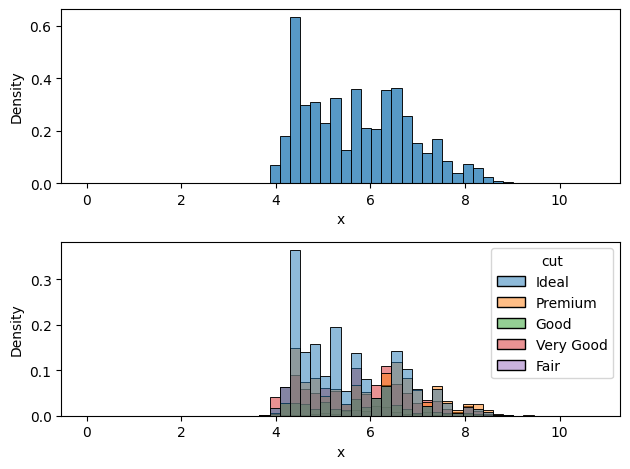

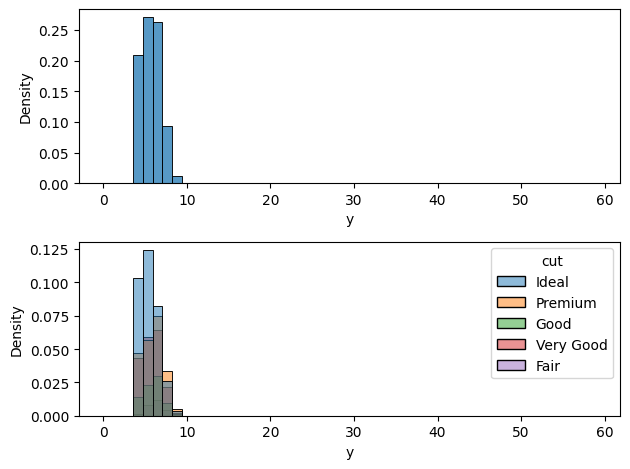

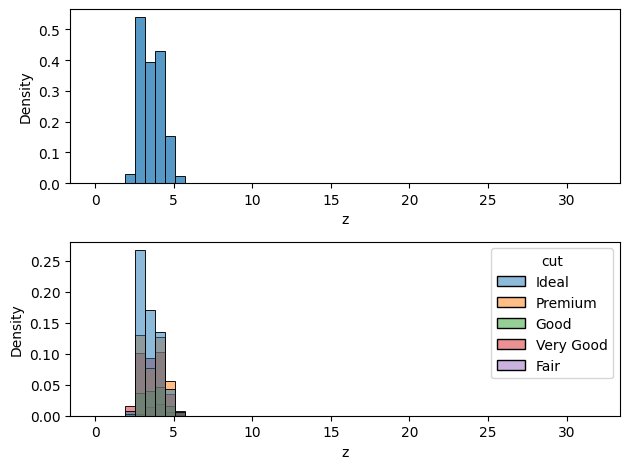

In [33]:
# The code for your plots go here

for col in df.columns:
    # if col == 'cut':  # considerei pular a coluna cut pois o segundo gráfico é estranho para essa coluna, 
    #     continue      # mas acabei deixando pois não foi específicado no enunciado
    fig, axs = plt.subplots(2, 1) 
    sns.histplot(data=df,
                x=col,
                bins=50,
                stat='density',
                ax=axs[0]
                )
    sns.histplot(data=df,
                x=col,
                bins=50,    # não funciona com color e clarity pois são categorias
                stat='density',
                ax=axs[1],
                hue='cut',
                # multiple='stack'  # só vi depois que na tarefa ta sobreposto
                )
    plt.tight_layout()  # resolve sobreposição
plt.show()  

## Binary Classification Building a PR curve

The goal of this exercise is to evaluate the performance of various pre-trained classification models in predicting whether a client will subscribe to a term deposit (`y = yes/no`) in the Bank Marketing dataset. To achieve this, we will generate PR curves for each algorithm and determine the area under the curve. Using these metrics, we will decide which classifier is best suited for the task.

Follow the instructions in the cells below to complete this task.

In [ ]:
# Loading the pre-trained classifiers and testing data
classifiers = pkl.load(open('../../models/classifiers_dict.p','rb'))
bank_marketing_test_data = pkl.load(open('../../data/bank_marketing_test_data.p','rb'))

The loaded variables are dictionaries. One contains the pre-trained classifiers and the other one the testing data. 

Let's inspect the contents of the classifiers_dict

In [35]:
classifiers

{'Categorical NB': Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('impute',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('bin',
                                                                    KBinsDiscretizer(encode='ordinal',
                                                                                     n_bins=8))]),
                                                   ['age', 'balance', 'day',
                                                    'duration', 'campaign',
                                                    'pdays', 'previous']),
                                                  ('cat',
                                                   Pipeline(steps=[('impute',
                                                                    SimpleIm

In [36]:
bank_marketing_test_data

{'X_test':       age           job  marital  education default  balance housing loan  \
 0      40   blue-collar  married    primary      no      640     yes  yes   
 1      44    technician  married  secondary      no      378     yes   no   
 2      31      services  married  secondary      no      356     yes   no   
 3      36   blue-collar  married    primary      no      655     yes   no   
 4      34      services   single  secondary      no     1921     yes   no   
 ...   ...           ...      ...        ...     ...      ...     ...  ...   
 9038   26   blue-collar   single  secondary      no     -333      no  yes   
 9039   49      services  married  secondary      no      884     yes   no   
 9040   32  entrepreneur  married   tertiary      no      964     yes   no   
 9041   20       student   single    primary      no        0      no   no   
 9042   39    management  married  secondary      no      363     yes  yes   
 
         contact  day month  duration  campaign  pda

* We can see that the key is the name of the classifier and the value contains the pre-trained instance of each classifier. 
* In the next code cell there's code to extract the classifiers into separate variables.

In [37]:
cnb_clf = classifiers['Categorical NB']
lr_clf = classifiers['Logistic Regression']
svm_clf = classifiers['SVM']

Next we'll extract the testing data from the `bank_marketing_test_data` dictionary we just loaded.

First, let's inspect the keys of the dictionary (we don't look at the values because the data is rather large and we don't want it to take up the whole screen).

In [38]:
bank_marketing_test_data.keys()

dict_keys(['X_test', 'y_test'])

* X_test contains the data points with their features that will serve as the input to our trained models.
* y_test contains the true labels for the testing set, which we'll use to evaluate our predictions.

In [39]:
X_test = bank_marketing_test_data['X_test']
y_test = bank_marketing_test_data['y_test']

As we can see below, `X_test` contains the features used to train the different classifiers for the Bank Marketing task.
* __Note__ that the index could be shuffled because this is a random subset of the original data that we are using as our testing set.

In [40]:
X_test.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,40,blue-collar,married,primary,no,640,yes,yes,unknown,8,may,347,2,-1,0,unknown
1,44,technician,married,secondary,no,378,yes,no,unknown,30,may,203,2,-1,0,unknown
2,31,services,married,secondary,no,356,yes,no,unknown,20,jun,228,5,-1,0,unknown
3,36,blue-collar,married,primary,no,655,yes,no,unknown,23,may,153,4,-1,0,unknown
4,34,services,single,secondary,no,1921,yes,no,cellular,4,feb,61,1,-1,0,unknown


In [41]:
X_test.shape, y_test.shape

((9043, 16), (9043,))

During class we looked at the case where the output of the classifier is a number between 0 and 1. This is the case for the classifiers we will use here. For these classifiers this output can be interpreted as the probabilities.

We are now going to obtain the predicted probabilities from our different classifiers
* To do this we are using the method `predict_proba()`
* This is a method specific to each classifier and it requires as input argument the datapoints of our testing set with their features (`X_test`).

In [42]:
y_proba_cnb = cnb_clf.predict_proba(X_test)
y_proba_svm = svm_clf.predict_proba(X_test)
y_proba_lr = lr_clf.predict_proba(X_test)

Let's inspect one of the variables we just created. 

We notice that it contains two values per row that sum up to 1. The first value is the probability of class 0 and the second value is the probability of class 1.

__For this exercise, you will use only the second column (probability of class 1) as was explained in class.__

In [43]:
y_proba_cnb # [:,1]

array([[0.99794241, 0.00205759],
       [0.99702456, 0.00297544],
       [0.99833108, 0.00166892],
       ...,
       [0.93185546, 0.06814454],
       [0.62026637, 0.37973363],
       [0.94504351, 0.05495649]], shape=(9043, 2))

## Calculating the precision and recall
Now that we have our predicted values and the true labels, we are ready to generate the PR curve

Feel free to define the function(s) in a way that you find most comfortable. The goal of these functions is to generate the precision and recall at different thresholds for all classifiers.

The cell below contains a suggestion on how you can structure the function -- you can also do it differently if you prefer.

In [44]:
# The following is just example code, it is not meant to be executed.
# def get_precision_recall(predicted_values, true_labels, threshold):
    # body of the function
    # return precision, recall
# this function would calculate the confusion matrix and then the precision and recall to return it as two separate values. 

# to then use the output values of this function you would do something like:
# precision, recall = get_precision_recall(y_proba_lr, y_test, threshold)

In [45]:
# Your code goes here!!

# precision = TP / (TP + FP)
# recall    = TP / (TP + FN) 

def get_precision_recall(predicted_values, true_labels, threshold):
    predicted_values_relevant_column = predicted_values[:,1]
    binary_predictions = (predicted_values_relevant_column >= threshold).astype(int)

    matriz_confusao = [[0, 0],[0, 0]]

    matriz_confusao[0][0] = ((binary_predictions == 0) & (true_labels == 0)).astype(int).sum()
    matriz_confusao[1][1] = ((binary_predictions == 1) & (true_labels == 1)).astype(int).sum()
    matriz_confusao[0][1] = ((binary_predictions == 1) & (true_labels == 0)).astype(int).sum()
    matriz_confusao[1][0] = ((binary_predictions == 0) & (true_labels == 1)).astype(int).sum()

    # if (true_pos + false_pos) == 0:
    #     print(threshold)
    #     print(true_pos + false_pos)

    precision = matriz_confusao[1][1] / (matriz_confusao[1][1] + matriz_confusao[0][1])
    recall = matriz_confusao[1][1] / (matriz_confusao[1][1] + matriz_confusao[1][0])

    return precision, recall 

threshold = 0.5 # exemplo de teste
precision, recall = get_precision_recall(y_proba_lr, y_test, threshold)
(precision, recall)


(np.float64(0.6444833625218914), np.float64(0.34782608695652173))

## Plotting the PR curve
Now let's use the calculated precisions and recalls to plot the PR curves for the different classifiers.

The template below provides the typical structure of a superimposed plot, but you're welcome to modify it to fit your needs.

In [46]:
# preparando os dados numa célula diferente para não precisar recalcular

PR_data_cnb = np.array([get_precision_recall(y_proba_cnb, y_test, p) for p in np.unique(y_proba_cnb[:,1])])
PR_data_svm = np.array([get_precision_recall(y_proba_svm, y_test, p) for p in np.unique(y_proba_svm[:,1])])
PR_data_lr  = np.array([get_precision_recall(y_proba_lr , y_test, p) for p in np.unique(y_proba_lr[:,1]) ])

In [47]:
PR_data_cnb_sorted = PR_data_cnb[PR_data_cnb[:,1].argsort()] 
PR_data_svm_sorted = PR_data_svm[PR_data_svm[:,1].argsort()] 
PR_data_lr_sorted = PR_data_lr[PR_data_lr[:,1].argsort()] 

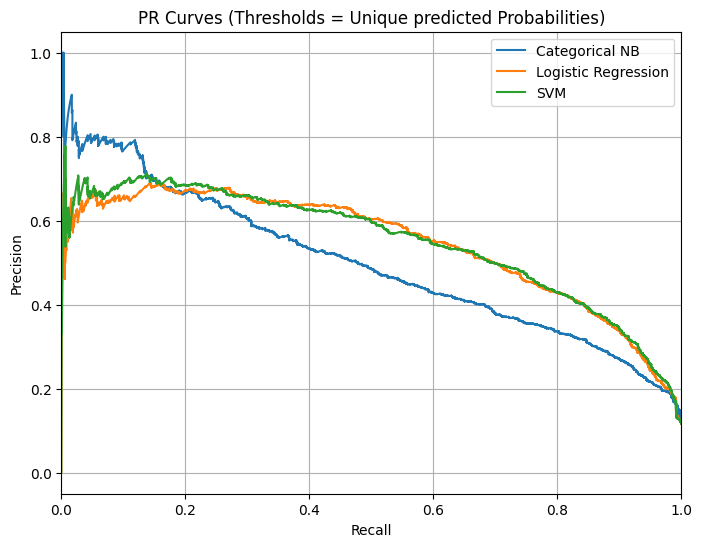

In [48]:
# Here you must complete the calls to plt.plot() with the right input arguments
# Following that you will need to generate the correct plot properties below

fig = plt.figure(figsize=(8,6))
# PR Curve for the Categorical Naive Bayes
plt.plot(PR_data_cnb_sorted[:,1], PR_data_cnb_sorted[:,0], label="Categorical NB")
# PR Curve for Logistic Regression
plt.plot(PR_data_lr_sorted[:,1], PR_data_lr_sorted[:,0], label="Logistic Regression")
# PR Curve for SVM
plt.plot(PR_data_svm_sorted[:,1], PR_data_svm_sorted[:,0], label="SVM")


# Plot properties
plt.xlim(left=0, right=1)
plt.grid(visible=True, 
         linestyle="-"
         )

# Title
plt.title("PR Curves (Thresholds = Unique predicted Probabilities)")

# X-Ticks and X-label 
plt.xticks(ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.xlabel(xlabel="Recall")

# Y-Ticks and Y-label
plt.yticks(ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.ylabel(ylabel="Precision")

# Legend
plt.legend()
plt.show()

You make the plot using a single call to a plotting function.
* _Tip: use pandas and seaborn for this_

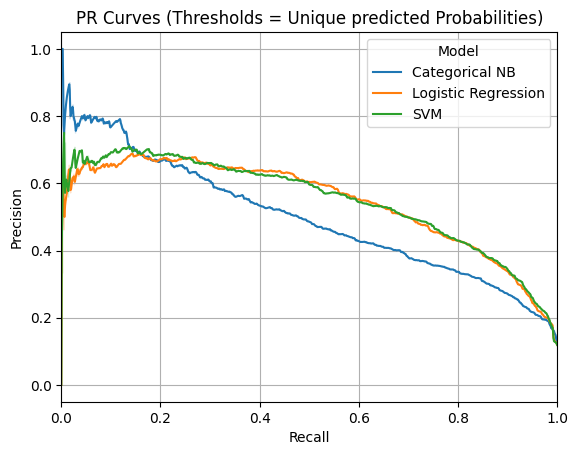

In [49]:
# Your code goes here

PR_data_cnb_sorted_df = pd.DataFrame(PR_data_cnb_sorted, columns=["Precision", "Recall"])
PR_data_cnb_sorted_df["Model"] = "Categorical NB"

PR_data_svm_sorted_df = pd.DataFrame(PR_data_svm_sorted, columns=["Precision", "Recall"])
PR_data_svm_sorted_df["Model"] = "SVM"

PR_data_lr_sorted_df = pd.DataFrame(PR_data_lr_sorted, columns=["Precision", "Recall"])
PR_data_lr_sorted_df["Model"] = "Logistic Regression"

PR_data_global_df = pd.concat([PR_data_cnb_sorted_df, PR_data_lr_sorted_df, PR_data_svm_sorted_df])


sns.lineplot(data=PR_data_global_df, 
             x="Recall", 
             y="Precision", 
             hue="Model"
             )

plt.xlim(left=0, right=1) # parâmetros do gráfico que precisam ser definidos fora da chamada de sns.lineplot
plt.grid(visible=True)
plt.title("PR Curves (Thresholds = Unique predicted Probabilities)")

plt.show()

## Area under the curve
You are not expected to code a function to calculate the area under the PR curve. Instead you have to use the provided function: `average_precision_score()` to obtain this value. 

_Make sure to check the relevant documentation for this sklearn function._
* __Important: remember that we only care about the second column of our predicted probabilities!__

In [ ]:
# Fill in your code where necessary
cnb_auprc = average_precision_score(y_test, y_proba_cnb[:,1])
print("The AUPRC for the Categorical Naive Bayes classifier is: {}".format(cnb_auprc))
svm_auprc =  average_precision_score(y_test, y_proba_svm[:,1])
print("The AUPRC for the SVM classifier is: {}".format(svm_auprc))
lr_auprc = average_precision_score(y_test, y_proba_lr[:,1])
print("The AUPRC for the Logistic Regression classifier is: {}".format(lr_auprc))

The AUPRC for the Categorical Naive Bayes classifier is: 0.49909420938608884
The AUPRC for the SVM classifier is: 0.5500318928957416
The AUPRC for the Logistic Regression classifier is: 0.5451315654132785


After analyzing the PR curves and calculating the area under the curves, it should be apparent that the SVM classifier outperforms the other classifiers and is the most suitable option for this particular problem.

## Regression RMSE

The final exercise of this coursework requires you to calculate the Root Mean Squared Error (RMSE) of a linear regression model that predicts house prices.

In [51]:
# Load the data and the pre-trained model
california_testing_data = pkl.load(open('data/california_housing_testing_data.p','rb'))
linear_regression_model = pkl.load(open('models/linear_regression_model.p','rb'))

Again, we extract the testing features and the true values in separate variables. 
* __Important:__ I use different variable names because X_test and y_test are being used for exercise 2. There's no need for this, but just to avoid confusion and to not step on pre-existing variables

In [52]:
X_test_california = california_testing_data['X_test']
y_test_california = california_testing_data['y_test']

In [53]:
X_test_california.shape, y_test_california.shape

((4128, 8), (4128,))

Let's now obtain the predicted values

In [54]:
y_predict_lin_reg = linear_regression_model.predict(X_test_california)

## Calculating RMSE
Now you have to write code to calculate the root mean squared error on the testing set for the linear regression model we just loaded.
At the end, just print the RMSE value for verification.
### IMPORTANT:
**Calculate the RMSE by vectorising your code, that is, no loops whatsoever!!**

In [55]:
# Your code goes here

# RMSE = sqrt( sum( (yn - tn)^2 ) / N )

dif_pred_true = y_predict_lin_reg - y_test_california
dif_pred_true_square = dif_pred_true ** 2

size = dif_pred_true_square.shape[0]
avg_dif = dif_pred_true_square.sum() / size
RMSE = avg_dif ** (1/2)

RMSE

np.float64(71131.25918417348)